# DBSCAN Clustering

## What is DBSCAN?

DBSCAN stands for **Density-Based Spatial Clustering of Applications with Noise**.

Unlike K-Means, DBSCAN does not require us to specify the number of clusters beforehand.

DBSCAN identifies clusters based on the density of data points.

### Main Parameters

1. `eps`
   - Maximum distance between two points to be considered neighbors.

2. `min_samples`
   - Minimum number of points required inside an `eps` neighborhood
     for a point to become a Core Point.

### DBSCAN Point Types

- **Core Point** → Has enough neighboring points.
- **Border Point** → Not dense enough itself, but lies near a Core Point.
- **Noise Point** → Does not belong to any dense region.

### Advantages

- Does not require `n_clusters`.
- Can find irregularly shaped clusters.
- Can identify outliers/noise.

### Limitations

- Sensitive to `eps` and `min_samples`.
- Can struggle when clusters have very different densities.
- Feature scaling is important.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [2]:
X, y = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

print("Shape:", X.shape)

Shape: (500, 2)


In [3]:
print("First 5 rows:")
print(X[:5])

print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])

First 5 rows:
[[ 0.83064015 -0.42505452]
 [ 0.75968444  0.82933468]
 [ 1.03911309 -0.48812556]
 [-0.28159147  0.96938044]
 [ 0.31569948  1.11145394]]

Number of samples: 500
Number of features: 2


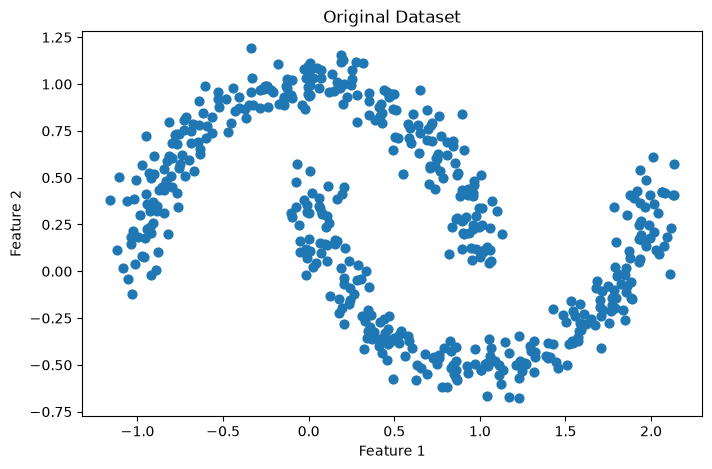

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Dataset")

plt.show()

## Feature Scaling

DBSCAN uses distance to determine whether points are neighbors.

Therefore, feature scales can strongly affect the result.

We use `StandardScaler` so that the features have approximately:

- Mean = 0
- Standard deviation = 1

This prevents one feature from dominating the distance calculation.

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.37087295 -1.34521023]
 [ 0.28949692  1.14654156]
 [ 0.60996153 -1.47049622]
 [-0.90469728  1.42473215]
 [-0.21969017  1.7069507 ]]


## What is eps?

`eps` defines the radius of the neighborhood around each point.

For example:

eps = 0.3

means DBSCAN looks for neighboring points within approximately
0.3 distance units.

### Small eps

Too small → Many points become noise.

### Large eps

Too large → Different clusters may merge.

Therefore:

**Choosing a good eps value is very important.**

## What is min_samples?

`min_samples` defines the minimum number of points required
inside the `eps` neighborhood.

Example:

min_samples = 5

means a point needs enough nearby points to qualify as a Core Point.

### Small min_samples

→ More points can become Core Points.

### Large min_samples

→ Fewer Core Points and potentially more noise.

In [6]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

print("Labels:", labels[:20])

Labels: [0 1 0 1 1 0 0 1 1 0 1 1 0 1 0 0 0 1 0 0]


In [7]:
unique_labels = set(labels)

print("Unique labels:", unique_labels)

n_clusters = len(unique_labels - {-1})

print("Number of clusters:", n_clusters)

Unique labels: {np.int64(0), np.int64(1)}
Number of clusters: 2


In [8]:
noise_count = np.sum(labels == -1)

print("Noise points:", noise_count)

Noise points: 0


In [9]:
cluster_counts = pd.Series(labels).value_counts().sort_index()

print(cluster_counts)

0    250
1    250
Name: count, dtype: int64


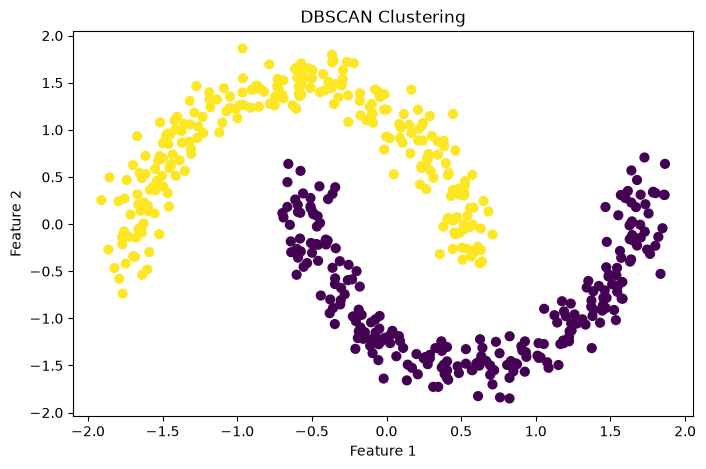

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=40
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering")

plt.show()

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.38355256771289353


## Silhouette Score

Silhouette Score measures how well-separated the clusters are.

Range:

- Close to +1 → Good separation
- Around 0 → Overlapping clusters
- Negative → Poor clustering

Higher is generally better.

However, clustering quality should not be judged using only one metric.